In [80]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score
import time
import shap
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.decomposition import PCA
import matplotlib.pyplot  as plt

In [59]:
class OutlierHandler(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds = {}
        self.upper_bounds = {}

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        for col in X_df.columns:
            Q1 = X_df[col].quantile(0.25)
            Q3 = X_df[col].quantile(0.75)
            IQR = Q3 - Q1
            self.lower_bounds[col] = Q1 - self.factor * IQR
            self.upper_bounds[col] = Q3 + self.factor * IQR
        return self

    def transform(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        for col in X_df.columns:
            # Capping (Winsorization)
            X_df[col] = np.where(X_df[col] < self.lower_bounds[col], self.lower_bounds[col], X_df[col])
            X_df[col] = np.where(X_df[col] > self.upper_bounds[col], self.upper_bounds[col], X_df[col])
        return X_df.values

In [60]:
df = pd.read_csv('./dataset/Mohammadinia_kg/heart_preprocess.csv')

In [61]:
df.duplicated().sum()

np.int64(0)

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                1319 non-null   int64  
 1   Age                       1319 non-null   int64  
 2   Gender                    1319 non-null   int64  
 3   Heart rate                1319 non-null   int64  
 4   Systolic blood pressure   1319 non-null   int64  
 5   Diastolic blood pressure  1319 non-null   int64  
 6   Blood sugar               1319 non-null   float64
 7   CK-MB                     1319 non-null   float64
 8   Troponin                  1319 non-null   float64
 9   Result                    1319 non-null   int64  
dtypes: float64(3), int64(7)
memory usage: 103.2 KB


In [63]:
df['Result'].value_counts()

Result
0    810
1    509
Name: count, dtype: int64

In [64]:
X = df.drop('Result', axis=1)
y = df['Result']

X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)


num_features = [
    "Age",                         # tuổi
    "Heart rate",    # enzyme CPK
    "Systolic blood pressure",           # EF (%)
    "Diastolic blood pressure",                   # tiểu cầu
    "Blood sugar",            # creatinine máu
    "CK-MB",    
    "Troponin"
]
cat_features = [
    "Gender"
    ]

In [65]:
Y_test.value_counts()

Result
0    162
1    102
Name: count, dtype: int64

In [66]:
Y_train.value_counts()

Result
0    648
1    407
Name: count, dtype: int64

PREPROCESSING DATA KNN-SVM-LR

In [67]:
num_pipeline_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("outlier", OutlierHandler()),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_scaled = ColumnTransformer([
    ("num", num_pipeline_scaled, num_features),
    ("cat", cat_pipeline, cat_features)
])

Decision Tree, Random Forest, Bagging

In [68]:
num_pipeline_no_scale = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocess_tree = ColumnTransformer([
    ("num", num_pipeline_no_scale, num_features),
    ("cat", cat_pipeline, cat_features)
])

XGBoost, AdaBoost

In [69]:
preprocess_boost = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), num_features),
    
    ("cat", cat_pipeline, cat_features)
])

In [70]:
CatBoostClassifier(cat_features=cat_features)

CatBoostClassifier(cat_features=['Gender'])

In [71]:
pipe_knn = Pipeline([
    ("preprocess", preprocess_scaled),
    ("model", KNeighborsClassifier())
])

pipe_lr = Pipeline([
    ("preprocess", preprocess_scaled),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_svm = Pipeline([
    ("preprocess", preprocess_scaled),
    ("model", SVC(probability=True))
])

pipe_dt = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", DecisionTreeClassifier())
])

pipe_rf = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", RandomForestClassifier())
])

pipe_bagging = Pipeline([
    ("preprocess", preprocess_tree),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=100
    ))
])

pipe_xgb = Pipeline([
    ("preprocess", preprocess_boost),
    ("model", XGBClassifier(eval_metric='logloss'))
])

pipe_ada = Pipeline([
    ("preprocess", preprocess_boost),
    ("model", AdaBoostClassifier())
])

pipe_cat = Pipeline([
    ("preprocess", preprocess_boost),
    ("model", CatBoostClassifier(verbose=0))
])

In [72]:
pipelines = {
    "KNN": pipe_knn,
    "LR": pipe_lr,
    "SVM": pipe_svm,
    "DT": pipe_dt,
    "RF": pipe_rf,
    "Bagging": pipe_bagging,
    "XGB": pipe_xgb,
    "Ada": pipe_ada,
    "CatBoost": pipe_cat
}

In [73]:
param_knn = {
    "model__n_neighbors": [3,5,7,9,11],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

param_lr = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

param_svm = {
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["rbf", "linear"],
    "model__gamma": ["scale", "auto"]
}

param_dt = {
    "model__max_depth": [3,5,10,20,None],
    "model__min_samples_split": [2,5,10],
    "model__min_samples_leaf": [1,2,4],
    "model__criterion": ["gini", "entropy"]
}

param_rf = {
    "model__n_estimators": [100,200,300],
    "model__max_depth": [None,5,10,20],
    "model__min_samples_split": [2,5],
    "model__min_samples_leaf": [1,2],
    "model__max_features": ["sqrt", "log2"]
}

param_bagging = {
    "model__n_estimators": [50,100,200],
    "model__max_samples": [0.5, 0.7, 1.0],
    "model__max_features": [0.5, 0.7, 1.0]
}

param_xgb = {
    "model__n_estimators": [100,200,300],
    "model__max_depth": [3,5,7],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

param_ada = {
    "model__n_estimators": [50,100,200],
    "model__learning_rate": [0.01, 0.1, 1]
}

param_cat = {
    "model__iterations": [100,200,300],
    "model__depth": [4,6,8],
    "model__learning_rate": [0.01, 0.1],
    "model__l2_leaf_reg": [1,3,5]
}

In [74]:
param_grids = {
    "KNN": param_knn,
    "LR": param_lr,
    "SVM": param_svm,
    "DT": param_dt,
    "RF": param_rf,
    "Bagging": param_bagging,
    "XGB": param_xgb,
    "Ada": param_ada,
    "CatBoost": param_cat
}

In [75]:
best_models = {}
evaluation_results = []

for name, pipe in pipelines.items():
    print(f"[{name}] Đang huấn luyện với GridSearchCV...")
    if name == 'SVM' or name == 'Bagging' or name == 'CatBoost':
        continue
    # 1. Huấn luyện GridSearchCV
    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
        return_train_score=True,
        verbose=1
    )
    
    start_time = time.time()
    
    grid.fit(X_train, Y_train)
    
    end_time = time.time()
    training_time = end_time - start_time
    
    best_models[name] = grid.best_estimator_
    
    
    best_idx = grid.best_index_
    
    # roc_auc trả về số âm, nên ta nhân -1 để có giá trị log_loss chuẩn (càng nhỏ càng tốt)
    train_loss = -grid.cv_results_['mean_train_score'][best_idx]
    val_loss_cv = -grid.cv_results_['mean_test_score'][best_idx]
    
    # 2. Dự đoán xác suất cho nhãn Positive (1)
    # SVM của bạn đã có probability=True nên predict_proba sẽ chạy bình thường
    y_probs = grid.best_estimator_.predict_proba(X_test)[:, 1]
    
    # 3. Tính toán ROC AUC và tìm ngưỡng cắt (Threshold) tối ưu
    auc = roc_auc_score(Y_test, y_probs)
    fpr, tpr, thresholds = roc_curve(Y_test, y_probs)
    
    # Sử dụng Youden's J statistic để tìm threshold cắt tối ưu (tối đa hoá tpr - fpr)
    J = tpr - fpr
    optimal_idx = np.argmax(J)
    optimal_threshold = thresholds[optimal_idx]
    
    # 4. Dự đoán dựa trên ngưỡng vừa tìm được
    y_pred = (y_probs >= optimal_threshold).astype(int)
    
    # 5. Đánh giá các độ đo khác
    acc = accuracy_score(Y_test, y_pred)
    prec = precision_score(Y_test, y_pred, zero_division=0)
    rec = recall_score(Y_test, y_pred, zero_division=0)
    
    evaluation_results.append({
        "Model": name,
        "Training Time (s)": round(training_time, 4),
        "AUC": auc,
        "Optimal Threshold": optimal_threshold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Best Params": grid.best_params_
    })
    print(grid.best_params_)
# Tạo DataFrame hiển thị kết quả
results_df = pd.DataFrame(evaluation_results)
results_df.sort_values(by="AUC", ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)

display(results_df)

[KNN] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'model__n_neighbors': 11, 'model__p': 1, 'model__weights': 'distance'}
[LR] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 5 candidates, totalling 25 fits


c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


{'model__C': 100, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
[SVM] Đang huấn luyện với GridSearchCV...
[DT] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 90 candidates, totalling 450 fits
{'model__criterion': 'gini', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}
[RF] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 96 candidates, totalling 480 fits
{'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
[Bagging] Đang huấn luyện với GridSearchCV...
[XGB] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.8}
[Ada] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
{'model__learning_rate': 0.1, 'mo

,Model,Training Time (s),AUC,Optimal Threshold,Accuracy,Precision,Recall,Best Params
0,XGB,41.5956,0.996036,0.783003,0.977273,0.952830,0.990196,"{'model__colsample_bytree': 1.0, 'model__learn..."
1,RF,109.0124,0.992435,0.749188,0.984848,0.962264,1.000000,"{'model__max_depth': 10, 'model__max_features'..."
2,Ada,8.8677,0.986293,0.629595,0.965909,0.918919,1.000000,"{'model__learning_rate': 0.1, 'model__n_estima..."
3,LR,0.7645,0.982510,0.503365,0.954545,0.916667,0.970588,"{'model__C': 100, 'model__penalty': 'l2', 'mod..."
4,DT,5.4975,0.981481,1.000000,0.977273,0.944444,1.000000,"{'model__criterion': 'gini', 'model__max_depth..."
5,KNN,14.4474,0.914488,0.515047,0.833333,0.723077,0.921569,"{'model__n_neighbors': 11, 'model__p': 1, 'mod..."


In [ ]:
if 'LR' in logistic_regression_models:
    lr_data = logistic_regression_models['LR']
    
    # Tạo DataFrame chi tiết
    lr_coefficients_df = pd.DataFrame({
        "Feature": lr_data["features"],
        "Coefficient": lr_data["coefficients"],
        "Abs_Coefficient": np.abs(lr_data["coefficients"]),
        "Impact": ["Positive" if coef > 0 else "Negative" for coef in lr_data["coefficients"]]
    })
    
    # Sắp xếp theo giá trị tuyệt đối giảm dần
    lr_coefficients_df = lr_coefficients_df.sort_values("Abs_Coefficient", ascending=False)
    lr_coefficients_df = lr_coefficients_df.round(4)
    
    print("\n" + "="*80)
    print("BẢNG HỆ SỐ HỒI QUY LOGISTIC REGRESSION")
    print("="*80)
    print(f"\nBest Parameters: {lr_data['best_params']}")
    print(f"AUC Score: {lr_data['auc']:.4f}")
    print("\n")
    
    # Hiển thị bảng
    from IPython.display import display
    display(lr_coefficients_df)
    
    # Lưu ra file CSV nếu muốn
    lr_coefficients_df.to_csv("logistic_regression_coefficients.csv", index=False)
    print("\n✅ Đã lưu file: logistic_regression_coefficients.csv")
    
    # ============================================
    # THỐNG KÊ TÓM TẮT
    # ============================================
    print("\n" + "="*80)
    print("THỐNG KÊ TÓM TẮT")
    print("="*80)
    
    positive_impact = lr_coefficients_df[lr_coefficients_df["Impact"] == "Positive"]
    negative_impact = lr_coefficients_df[lr_coefficients_df["Impact"] == "Negative"]
    
    print(f"\n📈 Features có tác động TÍCH CỰC (tăng nguy cơ bệnh): {len(positive_impact)} features")
    print(positive_impact[["Feature", "Coefficient"]].to_string(index=False))
    
    print(f"\n📉 Features có tác động TIÊU CỰC (giảm nguy cơ bệnh): {len(negative_impact)} features")
    print(negative_impact[["Feature", "Coefficient"]].to_string(index=False))
    
    # ============================================
    # VẼ BIỂU ĐỒ (tùy chọn)
    # ============================================
    plt.figure(figsize=(12, 7))
    colors = ['green' if coef > 0 else 'red' for coef in lr_coefficients_df["Coefficient"]]
    plt.barh(lr_coefficients_df["Feature"], lr_coefficients_df["Coefficient"], color=colors)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    plt.xlabel("Coefficient Value", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.title("Logistic Regression Coefficients - Feature Importance", fontsize=14)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Không tìm thấy mô hình Logistic Regression trong best_models")

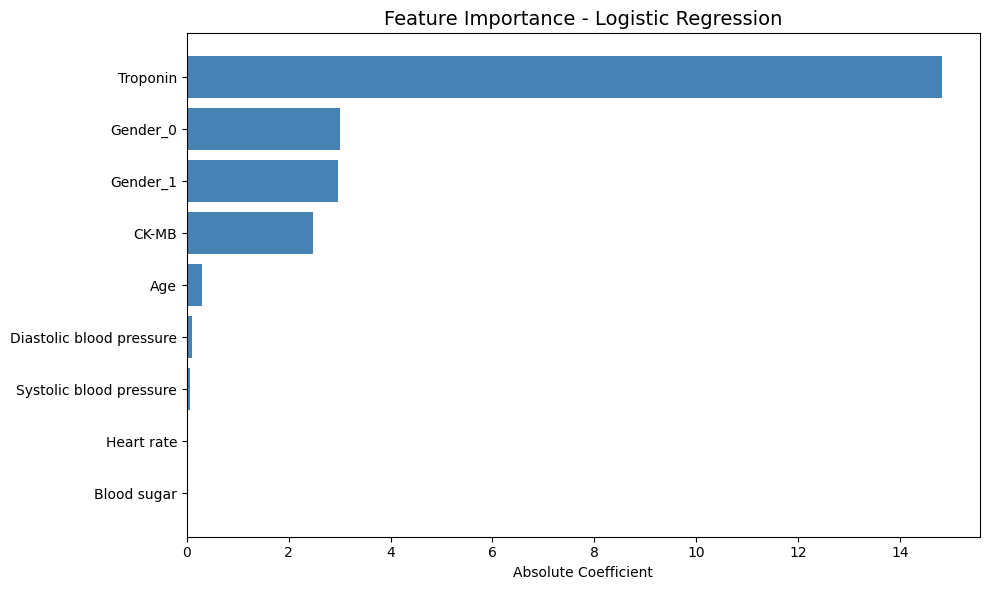

In [ ]:
# Lấy mô hình LR đã train tốt nhất (ví dụ từ cell số 18)
best_lr = best_models["LR"]  # Pipeline

# CÁCH 1: Lấy tên features trực tiếp từ danh sách đã khai báo (ĐƠN GIẢN NHẤT)
# Vì bạn đã biết rõ các features đầu vào
all_features = num_features + cat_features

# Lấy hệ số từ LogisticRegression
lr_model = best_lr.named_steps["model"]
coef_abs = np.abs(lr_model.coef_[0])

# Tạo DataFrame importance
import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": coef_abs
}).sort_values("Importance", ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.title("Feature Importance - Logistic Regression", fontsize=14)
plt.xlabel("Absolute Coefficient")
plt.tight_layout()
plt.show()

# In ra chi tiết
print("\nFeature Importance từ Logistic Regression:")
print(importance_df)

In [ ]:
smote_step = SMOTE(sampling_strategy=0.7)

pipe_knn = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("model", KNeighborsClassifier())
])

pipe_lr = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_svm = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("model", SVC(probability=True))
])

pipe_dt = ImbPipeline([
    ("preprocess", preprocess_tree),
    ("smote", smote_step),
    ("model", DecisionTreeClassifier(random_state=42))
])

pipe_rf = ImbPipeline([
    ("preprocess", preprocess_tree),
    ("smote", smote_step),
    ("model", RandomForestClassifier(random_state=42))
])

pipe_bagging = ImbPipeline([
    ("preprocess", preprocess_tree),
    ("smote", smote_step),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=100,
        random_state=42
    ))
])

pipe_xgb = ImbPipeline([
    ("preprocess", preprocess_boost),
    ("smote", smote_step),
    ("model", XGBClassifier(eval_metric='logloss', random_state=42))
])

pipe_ada = ImbPipeline([
    ("preprocess", preprocess_boost),
    ("smote", smote_step),
    ("model", AdaBoostClassifier(random_state=42))
])

pipe_cat = ImbPipeline([
    ("preprocess", preprocess_boost),
    ("smote", smote_step),
    ("model", CatBoostClassifier(verbose=0, random_state=42))
])

In [ ]:
pipelines_smote = {
    "KNN": pipe_knn,
    "LR": pipe_lr,
    "SVM": pipe_svm,
    "DT": pipe_dt,
    "RF": pipe_rf,
    "Bagging": pipe_bagging,
    "XGB": pipe_xgb,
    "Ada": pipe_ada,
    "CatBoost": pipe_cat
}

In [ ]:
best_models = {}
evaluation_results = []

for name, pipe in pipelines_smote.items():
    if name == 'SVM' or name == 'Bagging' or name == 'CatBoost':
        continue
    print(f"[{name}] Đang huấn luyện với GridSearchCV...")
    
    # 1. Huấn luyện GridSearchCV
    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
        return_train_score=True,
        verbose=1
    )
    
    start_time = time.time()
    
    grid.fit(X_train, Y_train)
    
    end_time = time.time()
    training_time = end_time - start_time
    
    best_models[name] = grid.best_estimator_
    
    
    best_idx = grid.best_index_
    
    # roc_auc trả về số âm, nên ta nhân -1 để có giá trị log_loss chuẩn (càng nhỏ càng tốt)
    train_loss = -grid.cv_results_['mean_train_score'][best_idx]
    val_loss_cv = -grid.cv_results_['mean_test_score'][best_idx]
    
    # 2. Dự đoán xác suất cho nhãn Positive (1)
    # SVM của bạn đã có probability=True nên predict_proba sẽ chạy bình thường
    y_probs = grid.best_estimator_.predict_proba(X_test)[:, 1]
    
    # 3. Tính toán ROC AUC và tìm ngưỡng cắt (Threshold) tối ưu
    auc = roc_auc_score(Y_test, y_probs)
    fpr, tpr, thresholds = roc_curve(Y_test, y_probs)
    
    # Sử dụng Youden's J statistic để tìm threshold cắt tối ưu (tối đa hoá tpr - fpr)
    J = tpr - fpr
    optimal_idx = np.argmax(J)
    optimal_threshold = thresholds[optimal_idx]
    
    # 4. Dự đoán dựa trên ngưỡng vừa tìm được
    y_pred = (y_probs >= optimal_threshold).astype(int)
    
    # 5. Đánh giá các độ đo khác
    acc = accuracy_score(Y_test, y_pred)
    prec = precision_score(Y_test, y_pred, zero_division=0)
    rec = recall_score(Y_test, y_pred, zero_division=0)
    
    evaluation_results.append({
        "Model": name,
        "Training Time (s)": round(training_time, 4),
        "AUC": auc,
        "Optimal Threshold": optimal_threshold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Best Params": grid.best_params_
    })
    #new
    print(grid.best_params_)
# Tạo DataFrame hiển thị kết quả
results_df = pd.DataFrame(evaluation_results)
results_df.sort_values(by="AUC", ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)

display(results_df)

[KNN] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'model__n_neighbors': 11, 'model__p': 1, 'model__weights': 'distance'}
[LR] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 5 candidates, totalling 25 fits


c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


{'model__C': 100, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
[SVM] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
{'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'linear'}
[DT] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 90 candidates, totalling 450 fits
{'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_leaf': 4, 'model__min_samples_split': 5}
[RF] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 96 candidates, totalling 480 fits
{'model__max_depth': None, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300}
[Bagging] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
{'model__max_features': 0.7, 'model__max_samples': 0.5, 'model__n_estimators': 100}
[XGB] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 108 candidates, totalling 540 fit

,Model,Training Time (s),AUC,Optimal Threshold,Accuracy,Precision,Recall,Best Params
0,RF,54.0374,0.999395,0.428175,0.992424,0.990196,0.990196,"{'model__max_depth': None, 'model__max_feature..."
1,Bagging,12.9775,0.998669,0.330000,0.992424,0.990196,0.990196,"{'model__max_features': 0.7, 'model__max_sampl..."
2,XGB,13.1844,0.997519,0.348566,0.992424,0.990196,0.990196,"{'model__colsample_bytree': 1.0, 'model__learn..."
3,CatBoost,142.8071,0.995945,0.165845,0.992424,0.990196,0.990196,"{'model__depth': 6, 'model__iterations': 300, ..."
4,DT,3.4769,0.994856,0.750000,0.992424,0.990196,0.990196,"{'model__criterion': 'gini', 'model__max_depth..."
5,Ada,3.5979,0.992556,0.507024,0.996212,1.000000,0.990196,"{'model__learning_rate': 1, 'model__n_estimato..."
6,SVM,5.5692,0.988683,0.442344,0.939394,0.877193,0.980392,"{'model__C': 10, 'model__gamma': 'auto', 'mode..."
7,LR,0.4573,0.983539,0.577115,0.943182,0.899083,0.960784,"{'model__C': 100, 'model__penalty': 'l2', 'mod..."
8,KNN,2.2143,0.928347,0.561041,0.852273,0.769231,0.882353,"{'model__n_neighbors': 11, 'model__p': 1, 'mod..."


In [ ]:

pca_step = PCA(random_state=42) # Để trống tham số này để Param Grid tự tune

# TẤT CẢ các model đều phải dùng preprocess_scaled vì có PCA
pipe_knn = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", KNeighborsClassifier())
])

pipe_lr = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", LogisticRegression(max_iter=1000))
])

pipe_svm = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", SVC(probability=True))
])

pipe_dt = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", DecisionTreeClassifier(random_state=42))
])

pipe_rf = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", RandomForestClassifier(random_state=42))
])

pipe_bagging = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=100,
        random_state=42
    ))
])

pipe_xgb = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", XGBClassifier(eval_metric='logloss', random_state=42))
])

pipe_ada = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", AdaBoostClassifier(random_state=42))
])

pipe_cat = ImbPipeline([
    ("preprocess", preprocess_scaled),
    ("smote", smote_step),
    ("pca", pca_step),
    ("model", CatBoostClassifier(verbose=0, random_state=42))
])

pipelines_smote_pca = {
    "KNN": pipe_knn,
    "LR": pipe_lr,
    "SVM": pipe_svm,
    "DT": pipe_dt,
    "RF": pipe_rf,
    "Bagging": pipe_bagging,
    "XGB": pipe_xgb,
    "Ada": pipe_ada,
    "CatBoost": pipe_cat
}

In [ ]:
param_knn = {
    "pca__n_components": [0.85, 0.90, 0.95],
    "model__n_neighbors": [3, 5, 7, 9, 11],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

param_lr = {
    "pca__n_components": [0.85, 0.90, 0.95],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

param_svm = {
    "pca__n_components": [0.85, 0.90, 0.95],
    "model__C": [0.1, 1, 10, 100],
    "model__kernel": ["rbf", "linear"],
    "model__gamma": ["scale", "auto"]
}

param_dt = {
    "pca__n_components": [0.85, 0.90, 0.95],
    "model__max_depth": [3, 5, 10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__criterion": ["gini", "entropy"]
}

param_rf = {
    "pca__n_components": [0.85, 0.90, 0.95],
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

param_bagging = {
    "pca__n_components": [0.85, 0.90, 0.95],
    "model__n_estimators": [50, 100, 200],
    "model__max_samples": [0.5, 0.7, 1.0],
    "model__max_features": [0.5, 0.7, 1.0]
}

param_xgb = {
    "pca__n_components": [0.85, 0.90, 0.95],
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.1, 0.2],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

param_ada = {
    "pca__n_components": [0.85, 0.90, 0.95],
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.1, 1]
}

param_cat = {
    "pca__n_components": [0.85, 0.90, 0.95],
    "model__iterations": [100, 200, 300],
    "model__depth": [4, 6, 8],
    "model__learning_rate": [0.01, 0.1]
    # Bỏ l2_leaf_reg đi bớt để giảm thời gian train nếu bạn kết hợp cả PCA
}

param_grids_smote_pca = {
    "KNN": param_knn,
    "LR": param_lr,
    "SVM": param_svm,
    "DT": param_dt,
    "RF": param_rf,
    "Bagging": param_bagging,
    "XGB": param_xgb,
    "Ada": param_ada,
    "CatBoost": param_cat
}

In [ ]:
best_models = {}
evaluation_results = []

for name, pipe in pipelines_smote_pca.items():
    if name == 'SVM' or name == 'Bagging' or name == 'CatBoost':
        continue
    print(f"[{name}] Đang huấn luyện với GridSearchCV...")
    
    # 1. Huấn luyện GridSearchCV
    grid = GridSearchCV(
        pipe,
        param_grids_smote_pca[name],
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
        return_train_score=True,
        verbose=1
    )
    
    start_time = time.time()
    
    grid.fit(X_train, Y_train)
    
    end_time = time.time()
    training_time = end_time - start_time
    
    best_models[name] = grid.best_estimator_
    
    
    best_idx = grid.best_index_
    
    # roc_auc trả về số âm, nên ta nhân -1 để có giá trị log_loss chuẩn (càng nhỏ càng tốt)
    train_loss = -grid.cv_results_['mean_train_score'][best_idx]
    val_loss_cv = -grid.cv_results_['mean_test_score'][best_idx]
    
    # 2. Dự đoán xác suất cho nhãn Positive (1)
    # SVM của bạn đã có probability=True nên predict_proba sẽ chạy bình thường
    y_probs = grid.best_estimator_.predict_proba(X_test)[:, 1]
    
    # 3. Tính toán ROC AUC và tìm ngưỡng cắt (Threshold) tối ưu
    auc = roc_auc_score(Y_test, y_probs)
    fpr, tpr, thresholds = roc_curve(Y_test, y_probs)
    
    # Sử dụng Youden's J statistic để tìm threshold cắt tối ưu (tối đa hoá tpr - fpr)
    J = tpr - fpr
    optimal_idx = np.argmax(J)
    optimal_threshold = thresholds[optimal_idx]
    
    # 4. Dự đoán dựa trên ngưỡng vừa tìm được
    y_pred = (y_probs >= optimal_threshold).astype(int)
    
    # 5. Đánh giá các độ đo khác
    acc = accuracy_score(Y_test, y_pred)
    prec = precision_score(Y_test, y_pred, zero_division=0)
    rec = recall_score(Y_test, y_pred, zero_division=0)
    
    evaluation_results.append({
        "Model": name,
        "Training Time (s)": round(training_time, 4),
        "AUC": auc,
        "Optimal Threshold": optimal_threshold,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Best Params": grid.best_params_
    })
    #new
    print(grid.best_params_)
# Tạo DataFrame hiển thị kết quả
results_df = pd.DataFrame(evaluation_results)
results_df.sort_values(by="AUC", ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)

display(results_df)

[KNN] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
{'model__n_neighbors': 11, 'model__p': 1, 'model__weights': 'distance', 'pca__n_components': 0.85}
[LR] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 15 candidates, totalling 75 fits


c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


{'model__C': 100, 'model__penalty': 'l2', 'model__solver': 'lbfgs', 'pca__n_components': 0.95}
[SVM] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
{'model__C': 100, 'model__gamma': 'auto', 'model__kernel': 'linear', 'pca__n_components': 0.95}
[DT] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 270 candidates, totalling 1350 fits
{'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'pca__n_components': 0.85}
[RF] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
{'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200, 'pca__n_components': 0.85}
[Bagging] Đang huấn luyện với GridSearchCV...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
{'model__max_features': 1.0, 'model__max_samples': 0.7, 'model__n_estimators': 50, 'pca__n_components':

,Model,Training Time (s),AUC,Optimal Threshold,Accuracy,Precision,Recall,Best Params
0,SVM,30.2317,0.988502,0.565932,0.946970,0.907407,0.960784,"{'model__C': 100, 'model__gamma': 'auto', 'mod..."
1,LR,3.2531,0.984144,0.566552,0.946970,0.907407,0.960784,"{'model__C': 100, 'model__penalty': 'l2', 'mod..."
2,XGB,167.6362,0.958303,0.441455,0.909091,0.842105,0.941176,"{'model__colsample_bytree': 1.0, 'model__learn..."
3,Ada,24.2392,0.948348,0.503044,0.890152,0.817391,0.921569,"{'model__learning_rate': 1, 'model__n_estimato..."
4,CatBoost,299.4951,0.944808,0.235108,0.856061,0.750000,0.941176,"{'model__depth': 6, 'model__iterations': 300, ..."
5,RF,188.7269,0.933854,0.473750,0.875000,0.789916,0.921569,"{'model__max_depth': 20, 'model__min_samples_l..."
6,Bagging,88.3261,0.924988,0.380000,0.856061,0.750000,0.941176,"{'model__max_features': 1.0, 'model__max_sampl..."
7,KNN,11.8431,0.919693,0.527760,0.840909,0.734375,0.921569,"{'model__n_neighbors': 11, 'model__p': 1, 'mod..."
8,DT,26.8586,0.882565,0.380952,0.806818,0.683453,0.931373,"{'model__criterion': 'entropy', 'model__max_de..."
